# Lab 3: RAG Improvements

In this section, we will use our metric-driven experimentation to improve our RAG system. We will do so by:
1. Implementing LlamaParse
2. Implementing hybrid search
3. Exploring the input prompts for llama-index RAG implementations.

_____
## Imports + Downloads

We need to download FlagEmbedding to allow for Milvus hybrid search. In particular, this will allow access to the BGE family of models. (https://github.com/FlagOpen/FlagEmbedding)

**FlagEmbedding** focuses on retrieval-augmented LLMs, consisting of the following projects currently:

- Long-Context LLM: Activation Beacon, LongLLM QLoRA
- Fine-tuning of LM : LM-Cocktail
- Embedding Model: Visualized-BGE, BGE-M3, LLM Embedder, BGE Embedding
- Reranker Model: llm rerankers, BGE Reranker
- Benchmark: C-MTEB, AIR-Bench, MLVU

In [1]:
%pip install FlagEmbedding
%pip install peft
%pip uninstall -y llama-index
%pip install -U llama-index --upgrade --no-cache-dir #--force-reinstall
%pip install pandas==2.2.2
%pip install llama-index-llms-google-genai
%pip install llama-parse llama-index-vector-stores-milvus pymilvus milvus python-dotenv

Found existing installation: llama-index 0.14.8
Uninstalling llama-index-0.14.8:
  Successfully uninstalled llama-index-0.14.8


In [2]:

import os
import pickle
import re
import ast
import gdown
import zipfile
import pandas as pd

from llama_index.llms.openai import OpenAI
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.core import VectorStoreIndex
from llama_index.core import Settings
from llama_parse import LlamaParse
from llama_index.core import SimpleDirectoryReader
from llama_index.core.node_parser import MarkdownElementNodeParser

from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.vector_stores.milvus import MilvusVectorStore
from llama_index.core.ingestion import IngestionPipeline

from datasets import Dataset

In [3]:
!wget https://raw.githubusercontent.com/ndecavel/tdwi-workshop-labs/main/data/Golden_Test_Data_DeepEval.csv

golden_df = pd.read_csv('/content/Golden_Test_Data_DeepEval.csv')
golden_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'], inplace=True)
golden_df = golden_df.rename(columns={'input':'question', 'expected_output':'ground_truth'})

--2025-11-24 19:25:33--  https://raw.githubusercontent.com/ndecavel/tdwi-llm/refs/heads/main/data/Golden_Test_Data_DeepEval.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 574872 (561K) [text/plain]
Saving to: ‘Golden_Test_Data_DeepEval.csv’

Golden_Test_Data_De 100%[===================>] 561.40K  --.-KB/s    in 0.07s   

2025-11-24 19:25:33 (8.15 MB/s) - ‘Golden_Test_Data_DeepEval.csv’ saved [574872/574872]



In [5]:
GPT_MODEL = 'gpt-5-mini'
TDS_FOLDER_PATH = "/content/downloaded_pdfs/"
NAIVE_COLLECTION_NAME = "Naive_RAG"

In [ ]:
### Download TDS documents
BEHR_FILE_PATH = '/content/Behr all products.xlsx'

# Workshop API keys. Paste the keys handed out in the room; do not commit them.
# Phase 8 replaces this cell with a call to the hub's /api/env endpoint.
os.environ["OPENAI_API_KEY"] = ""
# CLUSTER_ENDPOINT and ZILLIZ_API_KEY go away in phase 4b, with the cluster.
os.environ["CLUSTER_ENDPOINT"] = ""
os.environ["ZILLIZ_API_KEY"] = ""

!wget https://github.com/ndecavel/tdwi-workshop-labs/raw/main/data/Data_Resources_TDS.zip

# !unzip /content/Data_Resources_TDS.zip
with zipfile.ZipFile('/content/Data_Resources_TDS.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Download behr info file from gdrive
# gdown.download('https://docs.google.com/spreadsheets/d/1X812387sFClNqu1yc8JM_dE5bSOy9Da0nzM8zjXBGwQ/edit?gid=271516675#gid=271516675', BEHR_FILE_PATH, quiet=False)
file_id = '1X812387sFClNqu1yc8JM_dE5bSOy9Da0nzM8zjXBGwQ'
gdown.download(f'https://drive.google.com/uc?id={file_id}', BEHR_FILE_PATH, quiet=False)


____

In [7]:
df = pd.read_excel(BEHR_FILE_PATH)
df['File Name'] = df['TDS Link'].apply(lambda x: x.split('/')[-1].upper().replace('HTML', 'pdf'))
df.sample(3)

,Unnamed: 0,Product Name,Category,Subcategory,Product Main Link,Application,TDS Link,Interior Product,Exterior Product,Tools And Supplies Product,pdf_key,File Name
128,128,KILZ® ORIGINAL Low Odor Aerosol No. 1044,Interior Products,"{'interior-primers-sealers-and-undercoaters', ...",https://www.behr.com/pro/products/interior-pro...,"{'Primers Sealers And Undercoaters', 'Aerosol ...",https://www.behr.com/binaries/content/assets/b...,True,False,False,pdf_0128,1044_TDS_US.pdf
133,133,PREMIUM PLUS® Exterior Semi-Gloss Enamel No. 5050,Exterior Products,exterior-paints-and-coatings,https://www.behr.com/pro/products/exterior-pro...,Paints And Coatings,https://www.behr.com/binaries/content/assets/b...,False,True,False,pdf_0133,5050_TDS_US.pdf
38,38,BEHR PREMIUM® Interior/Exterior Concrete & Gar...,"{'Interior Products', 'Exterior Products'}",floor-coatings,https://www.behr.com/pro/products/interior-pro...,Floor Coating,https://www.behr.com/binaries/content/assets/b...,True,True,False,pdf_0038,900_TDS_US.pdf


The above sample shows the information that was used in compiling our dataset for this hands-on component.

In [8]:
embed_model = OpenAIEmbedding()
llm = OpenAI(model=GPT_MODEL)

Settings.llm = llm
Settings.embed_model = embed_model
documents = {}

In [10]:
### Commenting the below code out because it takes roughly ~1 min per document and has already been pre-run and added to the zilliz vector store
# import nest_asyncio

# nest_asyncio.apply()

# parser = LlamaParse(
#     api_key=### Here is where you would input your Llama Parse API Key,
#     # Select either markdown or text for the result type
#     result_type="markdown",
#     num_workers=4,
#     # The parsing mode
#     parse_mode="parse_page_with_agent",
#     # The model to use
#     model="openai-gpt-5-mini",
#     outlined_table_extraction=True,
#     output_tables_as_HTML=True,
#     verbose=True
# )


# # Iterate through files in TDS_FOLDER_PATH and extract markdown documents
# import glob
# for file in glob.glob(f"{TDS_FOLDER_PATH}/*.pdf"):
#   if file in documents:
#     continue
#   else:
#     documents[file] = await parser.aparse(file)


SyntaxError: invalid syntax (ipython-input-3363432998.py, line 9)

### Read more about Llama Parse here! https://www.llamaindex.ai/blog/launching-the-first-genai-native-document-parsing-platform

LlamaParse, developed by LlamaIndex, is the first GenAI-native document parsing platform, designed to harness the power of large language models (LLMs) for advanced document processing. Since its public release, it has attracted over 2,000 users and parsed over a million pages. Key features include:

- **GenAI-powered parsing instructions**: Users can give simple, natural-language directives to the parser, improving accuracy and efficiency for various document types, including rich tables, translated manga, and complex mathematical equations. This feature also enables tasks like sentiment analysis, language simplification, and translation.

- **JSON mode**: Provides a detailed programmatic format for precise parsing requirements. Outputs include:
  - Document structure
  - Marked tables, text, and headings
  - Images with metadata
  - CSV and JSON formats for tables

LlamaParse supports a wide range of document types beyond PDFs, such as Microsoft Word, PowerPoint, Rich Text Format, Apple Pages, and ePub books.

### Understanding hybrid search with RFR:

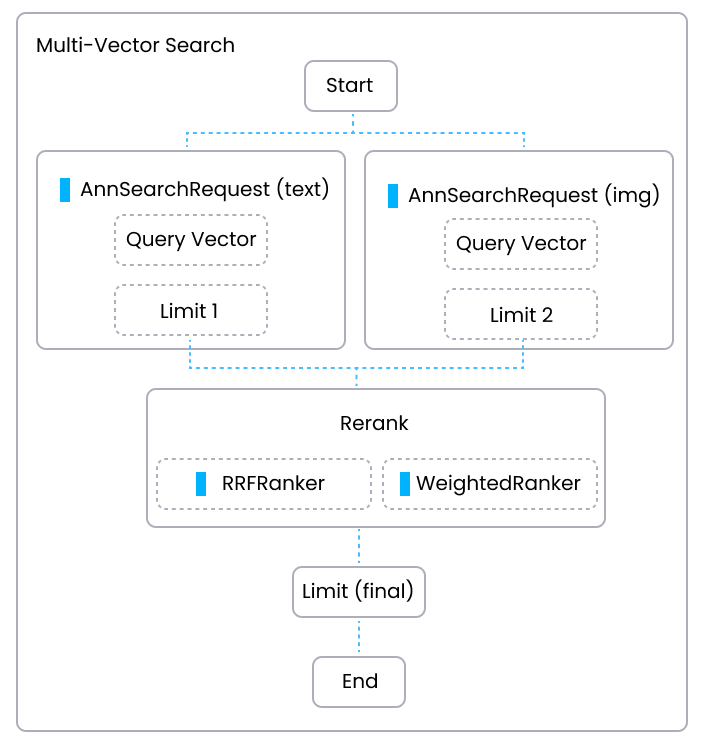

#### Weighted Scoring (WeightedRanker)
The WeightedRanker strategy assigns different weights to results from each vector retrieval route based on the significance of each vector field. This reranking strategy is applied when the significance of each vector field varies, allowing you to emphasize certain vector fields over others by assigning them higher weights. For example, in a multimodal search, the text description might be considered more important than the color distribution in images.


#### Reciprocal Rank Fusion (RRFRanker)


RRF is a data fusion method that combines ranking lists based on the reciprocal of their ranks. It is an effective way to balance the influence of each vector field, especially when there is no clear precedence of importance. This strategy is typically used when you want to give equal consideration to all vector fields or when there is uncertainty about the relative importance of each field.




(Context from Milvus documentation)

In [ ]:
## 1. Connect to the Zilliz Cloud cluster and create our collection
# PLEASE DO NOT CHANGE THE FOLLOWING PARAMETERS
vector_store = MilvusVectorStore(uri=os.getenv("CLUSTER_ENDPOINT"),
                             token=os.getenv("ZILLIZ_API_KEY"),
                              dim=1536,
                              collection_name=f"improved_vector_store",
                              overwrite=False,
                              enable_sparse=True,
                              hybrid_ranker="RRFRanker",
                              hybrid_ranker_params={"k": 60},
                          )

In [ ]:
### Following code is how we populated the index. Please leave commented out

### Create an index over the documents
# from llama_index.core import StorageContext
# storage_context = StorageContext.from_defaults(vector_store=vector_store)
# index = VectorStoreIndex.from_documents(
#     [doc.get_markdown_documents()[0] for doc in documents.values()], storage_context=storage_context
# )


In [ ]:
index = VectorStoreIndex.from_vector_store(vector_store)

____
### Now that we've made a few changes, let us experiment with how this may improve our RAG system.

In [ ]:
# Take a sample of 30 questions and compare with both naive and current RAG

naive_vector_store = MilvusVectorStore(uri=os.getenv("CLUSTER_ENDPOINT"),
                             token=os.getenv("ZILLIZ_API_KEY"),
                             dim=1536,
                             collection_name=f"{NAIVE_COLLECTION_NAME}",
                             similarity_metric='COSINE',
                             overwrite=False)


naive_index = VectorStoreIndex.from_vector_store(naive_vector_store)

naive_query_engine = naive_index.as_query_engine(similarity_top_k=5)

full_text_search_engine = index.as_query_engine(vector_store_query_mode="sparse", similarity_top_k=5)
hybrid_query_engine = index.as_query_engine(vector_store_query_mode="hybrid", similarity_top_k=5)

# sample_test_df = golden_df.sample(25)
sample_test_df = golden_df[golden_df['synthetic_input_quality'] == 1.0].sample(30)

In [ ]:
import tqdm
from tqdm.asyncio import tqdm_asyncio
import nest_asyncio
import asyncio

nest_asyncio.apply()

from llama_index.core import (
    VectorStoreIndex,
    SimpleDirectoryReader,
    Response,
)
from llama_index.llms.google_genai import GoogleGenAI
from llama_index.core.evaluation import FaithfulnessEvaluator, ContextRelevancyEvaluator, AnswerRelevancyEvaluator
from llama_index.core.evaluation import EvaluationResult

pd.set_option("display.max_colwidth", 0)

async def evaluate_query_engine(query_engine, questions):
    print(f"Evaluating query engine on {len(questions)} questions.")

    llm_model = GoogleGenAI(model='gemini-2.5-flash')

    faithful_eval = FaithfulnessEvaluator(llm=llm_model)
    context_relevancy_eval = ContextRelevancyEvaluator(llm=llm_model)
    answer_relevancy_eval = AnswerRelevancyEvaluator(llm=llm_model)

    # 1. Run Queries in parallel
    c = [query_engine.aquery(q) for q in questions]
    results = await tqdm_asyncio.gather(*c, desc="Running Queries")

    print("Finished Running Queries, now starting evals")

    evals = {}

    # 2. Run each evaluator type sequentially, but parallelize within each type
    for eval_name, eval_obj in [("faithful", faithful_eval),
                                ("context_relevancy", context_relevancy_eval),
                                ('answer_relevancy', answer_relevancy_eval)]:

        print(f"Running eval: {eval_name}")
        eval_tasks = []

        # Create all tasks for this evaluator type
        for question, r in zip(questions, results):
            contexts = [node.get_content() for node in r.source_nodes]

            if eval_name == 'faithful':
                task = eval_obj.aevaluate(response=r.response, query=question, contexts=contexts)
            elif eval_name == 'answer_relevancy':
                task = eval_obj.aevaluate(query=question, response=r.response)
            elif eval_name == 'context_relevancy':
                task = eval_obj.aevaluate(query=question, contexts=contexts)

            eval_tasks.append(task)

        # Run all tasks for this evaluator in parallel
        evals[eval_name] = await tqdm_asyncio.gather(*eval_tasks, desc=f"Eval: {eval_name}")

    return evals, results

# Run naive evals
naive_evals, naive_results = await evaluate_query_engine(naive_query_engine, sample_test_df['question'])

# Run full text search evals
full_text_evals, full_text_results = await evaluate_query_engine(full_text_search_engine, sample_test_df['question'])

# Run hybrid evals
hybrid_evals, hybrid_results = await evaluate_query_engine(hybrid_query_engine, sample_test_df['question'])

Evaluating query engine on 30 questions.


Running Queries: 100%|██████████| 30/30 [00:58<00:00,  1.95s/it]


Finished Running Queries, now starting evals
Running eval: faithful


Eval: faithful: 100%|██████████| 30/30 [00:16<00:00,  1.81it/s]


Running eval: context_relevancy


...

Eval: faithful: 100%|██████████| 30/30 [00:16<00:00,  1.77it/s]


Running eval: context_relevancy


Eval: context_relevancy: 100%|██████████| 30/30 [00:16<00:00,  1.80it/s]


Running eval: answer_relevancy


Eval: answer_relevancy: 100%|██████████| 30/30 [00:06<00:00,  4.45it/s]


In [ ]:
### Run the following cell to visualize the results and identify which approach performed better!
import numpy as np

def compare_eval_results_three_way(naive_evals, full_text_evals, hybrid_evals):
    """Compare naive, full text, and hybrid results in a tabular format"""

    # Aggregate comparison across all metrics
    print("=" * 100)
    print("AGGREGATE COMPARISON - ALL APPROACHES")
    print("=" * 100)

    comparison_data = []
    for metric_name in naive_evals.keys():
        naive_scores = [res.score for res in naive_evals[metric_name]]
        full_text_scores = [res.score for res in full_text_evals[metric_name]]
        hybrid_scores = [res.score for res in hybrid_evals[metric_name]]

        comparison_data.append({
            'Metric': metric_name,
            'Naive Mean': np.round(np.mean(naive_scores), 3),
            'Full Text Mean': np.round(np.mean(full_text_scores), 3),
            'Hybrid Mean': np.round(np.mean(hybrid_scores), 3),
            'Best Approach': max([
                ('Naive', np.mean(naive_scores)),
                ('Full Text', np.mean(full_text_scores)),
                ('Hybrid', np.mean(hybrid_scores))
            ], key=lambda x: x[1])[0],
            'Naive→FT Δ': np.round(np.mean(full_text_scores) - np.mean(naive_scores), 3),
            'Naive→Hybrid Δ': np.round(np.mean(hybrid_scores) - np.mean(naive_scores), 3),
        })

    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)

    # Per-question detailed comparison
    print("\n" + "=" * 100)
    print("PER-QUESTION COMPARISON")
    print("=" * 100)

    for metric_name in naive_evals.keys():
        print(f"\n{metric_name.upper()}")
        print("-" * 100)

        naive_results = naive_evals[metric_name]
        full_text_results = full_text_evals[metric_name]
        hybrid_results = hybrid_evals[metric_name]

        question_data = []
        for i, (naive_res, ft_res, hybrid_res) in enumerate(zip(naive_results, full_text_results, hybrid_results)):
            naive_score = np.round(naive_res.score, 3)
            ft_score = np.round(ft_res.score, 3)
            hybrid_score = np.round(hybrid_res.score, 3)

            # Determine winner
            max_score = max(naive_score, ft_score, hybrid_score)
            if hybrid_score == max_score:
                winner = '🟢 Hybrid'
            elif ft_score == max_score:
                winner = '🔵 Full Text'
            else:
                winner = '🔴 Naive'

            # Handle ties
            if sum([s == max_score for s in [naive_score, ft_score, hybrid_score]]) > 1:
                winner = '⚪ Tie'

            question_data.append({
                'Q #': i + 1,
                'Naive': naive_score,
                'Full Text': ft_score,
                'Hybrid': hybrid_score,
                'Winner': winner,
                'Range': np.round(max_score - min(naive_score, ft_score, hybrid_score), 3)
            })

        question_df = pd.DataFrame(question_data)
        display(question_df)

        # Show win/loss summary
        hybrid_wins = sum(1 for d in question_data if '🟢' in d['Winner'])
        ft_wins = sum(1 for d in question_data if '🔵' in d['Winner'])
        naive_wins = sum(1 for d in question_data if '🔴' in d['Winner'])
        ties = sum(1 for d in question_data if '⚪' in d['Winner'])

        print(f"\nSummary: Hybrid: {hybrid_wins} | Full Text: {ft_wins} | Naive: {naive_wins} | Ties: {ties}")

    # Overall verdict
    print("\n" + "=" * 100)
    print("OVERALL VERDICT")
    print("=" * 100)

    # Calculate total scores across all metrics
    total_naive = sum([np.mean([res.score for res in naive_evals[metric]])
                       for metric in naive_evals.keys()])
    total_ft = sum([np.mean([res.score for res in full_text_evals[metric]])
                    for metric in full_text_evals.keys()])
    total_hybrid = sum([np.mean([res.score for res in hybrid_evals[metric]])
                        for metric in hybrid_evals.keys()])

    rankings = sorted([
        ('Naive', total_naive),
        ('Full Text', total_ft),
        ('Hybrid', total_hybrid)
    ], key=lambda x: x[1], reverse=True)

    print(f"🥇 1st: {rankings[0][0]} (score: {np.round(rankings[0][1], 3)})")
    print(f"🥈 2nd: {rankings[1][0]} (score: {np.round(rankings[1][1], 3)})")
    print(f"🥉 3rd: {rankings[2][0]} (score: {np.round(rankings[2][1], 3)})")

    improvement_ft = total_ft - total_naive
    improvement_hybrid = total_hybrid - total_naive

    print(f"\nImprovements over Naive:")
    print(f"  Full Text:  {'+' if improvement_ft > 0 else ''}{np.round(improvement_ft, 3)}")
    print(f"  Hybrid:     {'+' if improvement_hybrid > 0 else ''}{np.round(improvement_hybrid, 3)}")

# Usage
compare_eval_results_three_way(naive_evals, full_text_evals, hybrid_evals)

AGGREGATE COMPARISON - ALL APPROACHES


,Metric,Naive Mean,Full Text Mean,Hybrid Mean,Best Approach,Naive→FT Δ,Naive→Hybrid Δ
0,faithful,0.933,0.900,1.000,Hybrid,-0.033,0.067
1,context_relevancy,0.825,0.869,0.865,Full Text,0.044,0.040
2,answer_relevancy,0.967,0.983,0.967,Full Text,0.017,0.000



PER-QUESTION COMPARISON

FAITHFUL
----------------------------------------------------------------------------------------------------


,Q #,Naive,Full Text,Hybrid,Winner,Range
0,1,1.0,1.0,1.0,⚪ Tie,0.0
1,2,1.0,0.0,1.0,⚪ Tie,1.0
2,3,1.0,1.0,1.0,⚪ Tie,0.0
3,4,1.0,1.0,1.0,⚪ Tie,0.0
4,5,1.0,0.0,1.0,⚪ Tie,1.0
5,6,1.0,1.0,1.0,⚪ Tie,0.0
6,7,1.0,1.0,1.0,⚪ Tie,0.0
7,8,1.0,1.0,1.0,⚪ Tie,0.0
8,9,1.0,1.0,1.0,⚪ Tie,0.0
9,10,1.0,1.0,1.0,⚪ Tie,0.0



Summary: Hybrid: 0 | Full Text: 0 | Naive: 0 | Ties: 30

CONTEXT_RELEVANCY
----------------------------------------------------------------------------------------------------


,Q #,Naive,Full Text,Hybrid,Winner,Range
0,1,0.875,0.500,0.950,🟢 Hybrid,0.450
1,2,1.000,1.000,1.000,⚪ Tie,0.000
2,3,0.875,1.000,1.000,⚪ Tie,0.125
3,4,0.812,1.000,1.000,⚪ Tie,0.188
4,5,0.625,0.625,0.500,⚪ Tie,0.125
5,6,1.000,1.000,0.875,⚪ Tie,0.125
6,7,1.000,1.000,1.000,⚪ Tie,0.000
7,8,1.000,0.875,1.000,⚪ Tie,0.125
8,9,1.000,1.000,1.000,⚪ Tie,0.000
9,10,1.000,1.000,1.000,⚪ Tie,0.000



Summary: Hybrid: 4 | Full Text: 5 | Naive: 0 | Ties: 21

ANSWER_RELEVANCY
----------------------------------------------------------------------------------------------------


,Q #,Naive,Full Text,Hybrid,Winner,Range
0,1,1.0,1.0,1.0,⚪ Tie,0.0
1,2,1.0,1.0,1.0,⚪ Tie,0.0
2,3,1.0,1.0,1.0,⚪ Tie,0.0
3,4,1.0,1.0,1.0,⚪ Tie,0.0
4,5,1.0,1.0,1.0,⚪ Tie,0.0
5,6,1.0,1.0,1.0,⚪ Tie,0.0
6,7,1.0,1.0,1.0,⚪ Tie,0.0
7,8,0.5,0.5,1.0,🟢 Hybrid,0.5
8,9,1.0,1.0,1.0,⚪ Tie,0.0
9,10,1.0,1.0,1.0,⚪ Tie,0.0



Summary: Hybrid: 1 | Full Text: 1 | Naive: 0 | Ties: 28

OVERALL VERDICT
🥇 1st: Hybrid (score: 2.832)
🥈 2nd: Full Text (score: 2.752)
🥉 3rd: Naive (score: 2.725)

Improvements over Naive:
  Full Text:  +0.027
  Hybrid:     +0.106


In [ ]:
def compare_all_approaches(naive_evals, full_text_evals, hybrid_evals):
    """Simplified three-way comparison"""

    all_approaches = {
        'Naive': naive_evals,
        'Full Text': full_text_evals,
        'Hybrid': hybrid_evals
    }

    # Summary table
    summary_data = []
    for metric_name in naive_evals.keys():
        row = {'Metric': metric_name}
        for approach_name, evals in all_approaches.items():
            scores = [res.score for res in evals[metric_name]]
            row[f'{approach_name} Mean'] = np.round(np.mean(scores), 3)
        summary_data.append(row)

    summary_df = pd.DataFrame(summary_data)

    # Add "Best" column
    approach_cols = [col for col in summary_df.columns if 'Mean' in col]
    summary_df['Best'] = summary_df[approach_cols].idxmax(axis=1).str.replace(' Mean', '')

    print("=" * 80)
    print("SUMMARY COMPARISON")
    print("=" * 80)
    display(summary_df)

    # Calculate total scores across all metrics
    total_naive = sum([np.mean([res.score for res in naive_evals[metric]])
                       for metric in naive_evals.keys()])
    total_ft = sum([np.mean([res.score for res in full_text_evals[metric]])
                    for metric in full_text_evals.keys()])
    total_hybrid = sum([np.mean([res.score for res in hybrid_evals[metric]])
                        for metric in hybrid_evals.keys()])

    rankings = sorted([
        ('Naive', total_naive),
        ('Full Text', total_ft),
        ('Hybrid', total_hybrid)
    ], key=lambda x: x[1], reverse=True)

    print("\n" + "=" * 80)
    print("OVERALL VERDICT")
    print("=" * 80)
    print(f"🥇 1st: {rankings[0][0]} (score: {np.round(rankings[0][1], 3)})")
    print(f"🥈 2nd: {rankings[1][0]} (score: {np.round(rankings[1][1], 3)})")
    print(f"🥉 3rd: {rankings[2][0]} (score: {np.round(rankings[2][1], 3)})")

    improvement_ft = total_ft - total_naive
    improvement_hybrid = total_hybrid - total_naive

    print(f"\nImprovements over Naive:")
    print(f"  Full Text:  {'+' if improvement_ft > 0 else ''}{np.round(improvement_ft, 3)}")
    print(f"  Hybrid:     {'+' if improvement_hybrid > 0 else ''}{np.round(improvement_hybrid, 3)}")

# Usage
compare_all_approaches(naive_evals, full_text_evals, hybrid_evals)

SUMMARY COMPARISON


,Metric,Naive Mean,Full Text Mean,Hybrid Mean,Best
0,faithful,0.933,0.900,1.000,Hybrid
1,context_relevancy,0.825,0.869,0.865,Full Text
2,answer_relevancy,0.967,0.983,0.967,Full Text



OVERALL VERDICT
🥇 1st: Hybrid (score: 2.832)
🥈 2nd: Full Text (score: 2.752)
🥉 3rd: Naive (score: 2.725)

Improvements over Naive:
  Full Text:  +0.027
  Hybrid:     +0.106


## Prompts!

One thing we haven't explored yet with RAG is the specific prompts being used behind the scenes. How does it combine our question with the context? We can answer this by viewing the prompts of our query engine! This is where we can easily change these prompts if we would like to, but note that you would want to make sure certain mappings for the *context_str* and the *query_str* are consistent.






In [ ]:

from IPython.display import Markdown, display

# define prompt viewing function
def display_prompt_dict(prompts_dict):
    for k, p in prompts_dict.items():
        text_md = f"**Prompt Key**: {k}" f"**Text:** "
        display(Markdown(text_md))
        print(p.get_template())
        display(Markdown(""))

prompts_dict = hybrid_query_engine.get_prompts()
display_prompt_dict(prompts_dict)

**Prompt Key**: response_synthesizer:text_qa_template**Text:** 

Context information is below.
---------------------
{context_str}
---------------------
Given the context information and not prior knowledge, answer the query.
Query: {query_str}
Answer: 


**Prompt Key**: response_synthesizer:refine_template**Text:** 

The original query is as follows: {query_str}
We have provided an existing answer: {existing_answer}
We have the opportunity to refine the existing answer (only if needed) with some more context below.
------------
{context_msg}
------------
Given the new context, refine the original answer to better answer the query. If the context isn't useful, return the original answer.
Refined Answer: 
